In [6]:
# Importing Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score,confusion_matrix,classification_report
import joblib

In [7]:
# Loading dataset
df =pd.read_excel(r"C:\Users\Admin\Desktop\Shrawani\Projects\EV\EV intelligence system\data\EV_data.xlsx")

In [8]:
# first 5 rows from dataset
df.head()

,Time,Speed,Crank,Ignition,A_Batt_Current,A_Batt_Voltage,B_Batt_Current,B_Batt_Voltage,A_Batt_soc,B_Batt_soc,...,MCU_Speed,MCU_Current_DC,MCU_Voltage_DC,MCU_AC_Voltage[V],MCU_AC_Current[A],Odometer,Unnamed: 27,Unnamed: 28,KWH,Odo
0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,0.1,0,0,1,0.0,689.0,0.0,689.0,100.0,100.0,...,0,0.0,11.3,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,0.2,0,0,1,0.0,689.1,0.0,689.1,100.0,100.0,...,0,0.0,11.1,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,0.3,0,0,1,0.0,689.2,0.0,689.2,100.0,100.0,...,0,0.0,11.1,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,0.4,0,0,1,0.0,689.3,0.0,689.3,100.0,100.0,...,0,0.0,11.3,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167908 entries, 0 to 167907
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Time                     167908 non-null  float64
 1   Speed                    167908 non-null  int64  
 2   Crank                    167908 non-null  int64  
 3   Ignition                 167908 non-null  int64  
 4   A_Batt_Current           167908 non-null  float64
 5   A_Batt_Voltage           167908 non-null  float64
 6   B_Batt_Current           167908 non-null  float64
 7   B_Batt_Voltage           167908 non-null  float64
 8   A_Batt_soc               167908 non-null  float64
 9   B_Batt_soc               167908 non-null  float64
 10  B_Batt_Charge_energy     167908 non-null  float64
 11  B_Batt_Discharge_energy  167908 non-null  float64
 12  B_Batt_Regen_energy      167908 non-null  float64
 13  A_Batt_Charge_energy     167908 non-null  float64
 14  A_Ba

In [10]:
# Check missing values
df.isnull().sum()

Time                            0
Speed                           0
Crank                           0
Ignition                        0
A_Batt_Current                  0
A_Batt_Voltage                  0
B_Batt_Current                  0
B_Batt_Voltage                  0
A_Batt_soc                      0
B_Batt_soc                      0
B_Batt_Charge_energy            0
B_Batt_Discharge_energy         0
B_Batt_Regen_energy             0
A_Batt_Charge_energy            0
A_Batt_Discharge energy         0
A_Batt_Regen_energy             0
Torque                          0
MCU_temp                        0
Motor_temp                      0
Accel_pedal                     0
MCU_torque                      0
MCU_Speed                       0
MCU_Current_DC                  0
MCU_Voltage_DC                  0
MCU_AC_Voltage[V]               0
MCU_AC_Current[A]               0
Odometer                        0
Unnamed: 27                167908
Unnamed: 28                167908
KWH           

In [11]:
# check duplicae values
df.duplicated().sum()

np.int64(0)

In [12]:
#Let's remove unnessesary rows by considering valid conditions

In [13]:
df=df[(df["Ignition"]==1) & (df["Crank"]==1) & (df["Speed"]>0)].reset_index(drop=True)

In [14]:
df.shape

(145058, 31)

## Feature Engineering

In [15]:
# Time

In [16]:
df["dt"]=df["Time"].diff().fillna(0.1)

### Power

In [17]:
df['Power_A'] = df['A_Batt_Voltage'] * df['A_Batt_Current']
df['Power_B'] = df['B_Batt_Voltage'] * df['B_Batt_Current']
df['Total_Power'] = df['Power_A'] + df['Power_B']

### Driving Dynamics

In [18]:
window=600
df['Acceleration'] = (df['Speed'].diff().rolling(window).sum()/df["dt"]).fillna(0.0)
df['Jerk'] = (df['Acceleration'].diff().rolling(window).sum()/df["dt"]).fillna(0.0)

### Torque

In [19]:
df['Torque_Load'] = df['Torque'] * df['Speed']
df['Torque_Ratio'] = df['Torque'] / (df['Speed']+1)

### Thermal Features

In [20]:
df['Temp_diff'] = df['Motor_temp'] - df['MCU_temp']

### SOC change

In [21]:
df["Total_SOC"]=df["A_Batt_soc"]+df["B_Batt_soc"]

In [22]:
df['SOC_drop'] = df['Total_SOC'].diff().fillna(0)

# Target Variable

### for Energy Prediction (Regression)

In [23]:
df["Total_Discharge_energy"]=df["A_Batt_Discharge energy"]+df["B_Batt_Discharge_energy"]

### for Driving Style Classification (Classificaion)

In [24]:
df['Driving_style'] = pd.cut(
    df['Accel_pedal'],
    bins=[0, 30, 70, 100],
    labels=['Eco', 'Normal', 'Aggressive'],
    include_lowest=True # bcoz  my dataset has 0 values in accel_pedal col
)

# Model 1: Energy Prediction (Regression)

In [25]:
features = [
    'Speed','Torque','MCU_torque','Accel_pedal',
    'MCU_Current_DC','MCU_Voltage_DC',
    'Motor_temp','MCU_temp',
    'Torque_Load','Acceleration','SOC_drop'
]

In [26]:
X=df[features]

In [27]:
y=df["Total_Discharge_energy"]

In [28]:
# Train-test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [30]:
reg_model = RandomForestRegressor(n_estimators=100)


In [31]:
reg_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# model Evaluation

In [33]:
y_test_pred=reg_model.predict(X_test)

In [34]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

MAE: 0.4719445190389953
R2: 0.9983498759707568


# Model 2: Driving Style Classification

In [35]:
features = [
    'Speed','Torque','MCU_torque',
    'MCU_Current_DC','MCU_Voltage_DC',
    'Motor_temp','MCU_temp',
    'Torque_Load','Acceleration','SOC_drop'
]

In [36]:
X_cls = df[features]
y_cls = df['Driving_style']

In [37]:
# train-test-split

In [38]:
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X_cls, y_cls, test_size=0.2,random_state=42)

### Model building using Random Forest algorithm

In [39]:
clf = RandomForestClassifier()

In [40]:
clf.fit(X_cls_train, y_cls_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred_cls = clf.predict(X_cls_test)
print(classification_report(y_cls_test, y_pred_cls))

              precision    recall  f1-score   support

  Aggressive       0.93      0.93      0.93     10745
         Eco       0.96      0.92      0.94      2812
      Normal       0.94      0.95      0.94     15455

    accuracy                           0.94     29012
   macro avg       0.94      0.93      0.94     29012
weighted avg       0.94      0.94      0.94     29012



In [42]:
# Let's plot confusion matrix

<Axes: >

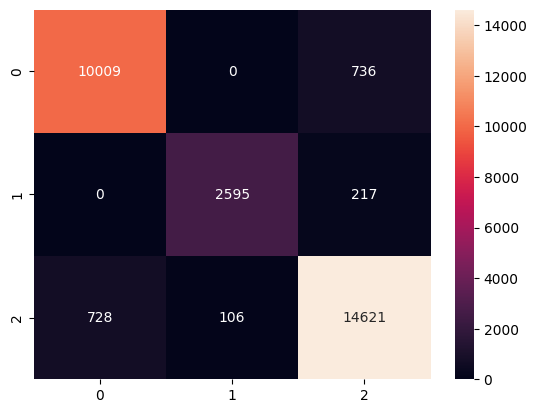

In [43]:
cm = confusion_matrix(y_cls_test, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d')

# Explainability using SHAP

In [44]:
import shap

c:\Users\Admin\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [45]:
X_sample = X_cls_test.sample(1000, random_state=42)

In [46]:
explainer = shap.TreeExplainer(clf)

In [47]:
shap_values = explainer.shap_values(X_sample)

In [48]:
# For Aggressive class

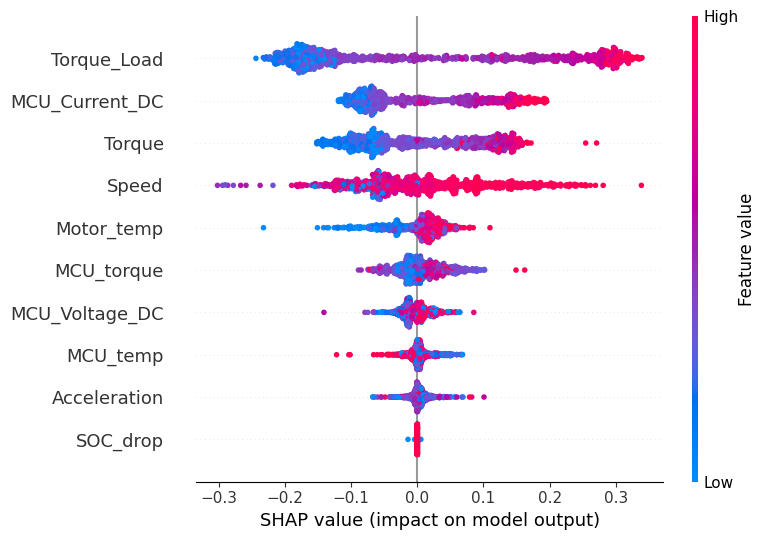

In [49]:
shap.summary_plot(shap_values[:, :, 0], X_sample)

In [50]:
# For Eco class

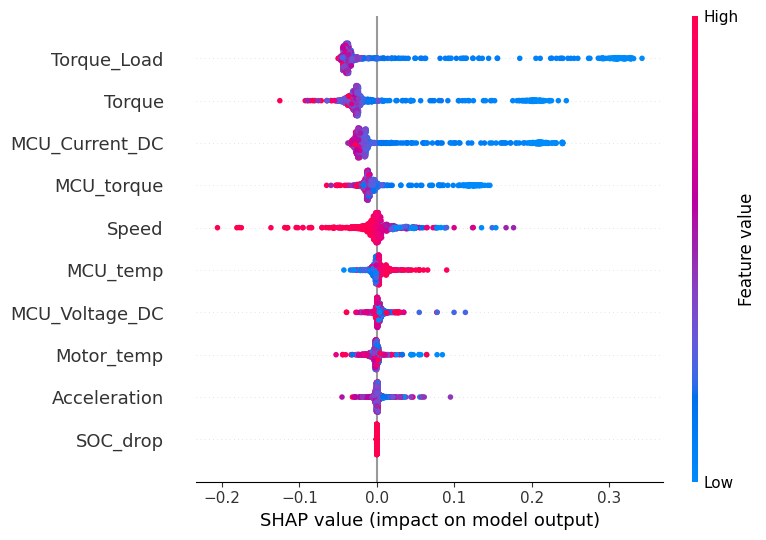

In [51]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

In [52]:
# For Normal class

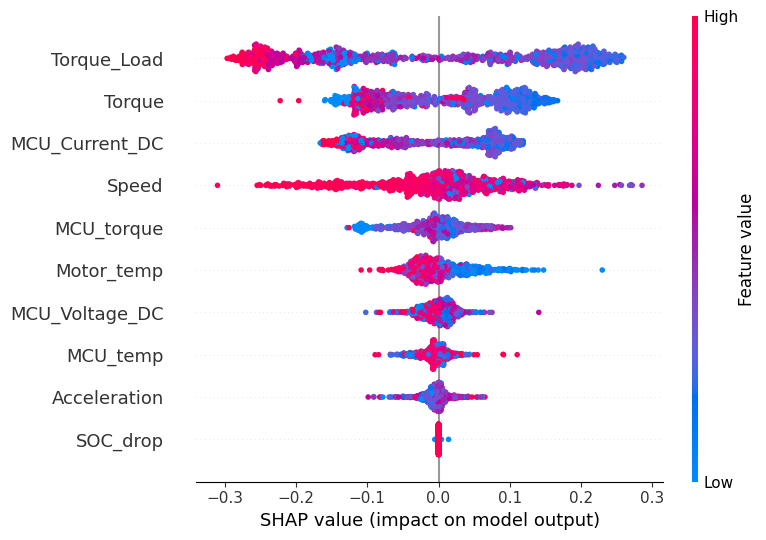

In [53]:
shap.summary_plot(shap_values[:, :, 2], X_sample)

In [54]:
joblib.dump(clf, "model.pkl")

['model.pkl']